# 메일 -> CSV

In [84]:
# 메일 분류
def classify_mail(subject, body):
    text = (subject + " " + body).lower()

    categories = {
        "업무협조": [
            "협조", "요청", "부탁", "전달", "회신", "확인", "처리", "검토", "승인", "진행", "지원", "일정 요청", "자료 요청", "공유 요청", "확인 부탁", "전달 부탁"
        ],
        "보고서": [
            "보고", "결과", "분석", "현황", "매출", "데이터", "통계", "성과", "개선", "지표", "리포트", "요약"
        ],
        "회의록": [
            "회의", "회의록", "안건", "참석자", "일정", "논의", "결정", "진행", "의결", "회의 결과"
        ],
        "공지": [
            "공지", "안내", "알림", "변경", "일정", "공지사항", "배포", "적용", "공지드립니다", "참고"
        ]
    }

    scores = {key: 0 for key in categories}

    for category, keywords in categories.items():
        for kw in keywords:
            if kw in text:
                scores[category] += 1

    # 점수 가장 높은 카테고리 선택
    best_category = max(scores, key=scores.get)

    # 전부 0이면 fallback
    if scores[best_category] == 0:
        return "공지"  # 기본값 (가장 범용적)

    return best_category

In [85]:
# 회신 여부 분류
def detect_action(body):
    need_reply_keywords = [
        "회신", "답변", "의견 부탁", "피드백", "확인 부탁",
        "검토 후 회신", "회신 요청", "답장"
    ]

    for kw in need_reply_keywords:
        if kw in body:
            return "회신 필요"

    return "회신 불필요"

In [86]:
from datetime import datetime

def normalize_date(date_str):
    today = datetime.today()

    # yyyy-mm-dd or yyyy.mm.dd
    try:
        return datetime.strptime(date_str, "%Y-%m-%d").strftime("%Y-%m-%d")
    except:
        pass
    try:
        return datetime.strptime(date_str, "%Y.%m.%d").strftime("%Y-%m-%d")
    except:
        pass

    # mm-dd or mm.dd → 올해 기준
    try:
        dt = datetime.strptime(date_str, "%m-%d")
        return dt.replace(year=today.year).strftime("%Y-%m-%d")
    except:
        pass
    try:
        dt = datetime.strptime(date_str, "%m.%d")
        return dt.replace(year=today.year).strftime("%Y-%m-%d")
    except:
        pass

    # "5월 10일"
    m = re.match(r"(\d{1,2})월\s?(\d{1,2})일", date_str)
    if m:
        month, day = map(int, m.groups())
        return f"{today.year}-{month:02d}-{day:02d}"

    return None

# 기한 추출
def extract_deadline(text):
    deadline_keywords = ["까지", "마감", "기한", "종료", "회신", "제출", "응답", "완료"]

    date_patterns = [
        r"\d{4}[.-]\d{2}[.-]\d{2}",
        r"\d{1,2}월\s?\d{1,2}일",
        r"\d{1,2}/\d{1,2}",
        r"\d{1,2}[.-]\d{1,2}"
    ]

    lines = text.split("\n")

    for line in lines:
        if not any(k in line for k in deadline_keywords):
            continue

        for pattern in date_patterns:
            match = re.search(pattern, line)
            if match:
                normalized = normalize_date(match.group())
                if normalized:
                    return normalized
    
    return "-"

In [87]:
import imaplib
import email
from email.header import decode_header
import os
import pdfplumber
IMAP_SERVER = "imap.gmail.com"
EMAIL = 'mhnkms8041@gmail.com'
PASSWORD = 'qxvh ihup erwd ppgn'
SAVE_DIR = "./downloads"
os.makedirs(SAVE_DIR, exist_ok=True)
# 1. IMAP 접속
mail = imaplib.IMAP4_SSL(IMAP_SERVER)
mail.login(EMAIL, PASSWORD)
mail.select("inbox")

('OK', [b'25'])

In [88]:
# 2. 메일 검색 (제목 필터는 직접 처리)
result, data = mail.search(None, "ALL")
mail_ids = data[0].split()
mail_csv_list = []
target_mail = None
# 최근 메일부터 역순 탐색
for mail_id in reversed(mail_ids):
    result, data = mail.fetch(mail_id, "(RFC822)")
    raw_email = data[0][1]
    msg = email.message_from_bytes(raw_email)

    subject, encoding = decode_header(msg["Subject"])[0]
    if isinstance(subject, bytes):
        subject = subject.decode(encoding or "utf-8")

    # 필터 없이 전부 저장하거나 조건 유지 가능
    mail_csv_list.append(msg)
    # if "[업무협조]" in subject:
    #     print("대상 메일:", subject)
    #     mail_csv_list.append(msg)

In [89]:
import csv
import re
import shutil

csv_path = "email_list.csv"
file_exists = os.path.isfile(csv_path)

with open(csv_path, "a", newline="", encoding="utf-8-sig") as csvfile:
    writer = csv.writer(csvfile)

    if not file_exists:
        # writer.writerow(["제목", "발신자", "분류", "회신", "기한", "요약"])
        writer.writerow(["제목", "발신자", "분류", "회신 필요 여부", "기한"])

    for mail_item in mail_csv_list:

        subject, encoding = decode_header(mail_item["Subject"])[0]
        if isinstance(subject, bytes):
            subject = subject.decode(encoding or "utf-8")

        from_ = str(email.header.make_header(decode_header(mail_item.get("From"))))

        full_text = ""
        saved_files = []   # ← 파일 경로 저장용

        for part in mail_item.walk():
            content_disposition = part.get("Content-Disposition")

            if part.get_content_type() == "text/plain" and "attachment" not in str(content_disposition):
                body = part.get_payload(decode=True)
                if body:
                    full_text += body.decode("utf-8", errors="ignore") + "\n"

            if content_disposition and "attachment" in content_disposition:
                filename = part.get_filename()

                if filename:
                    filename, enc = decode_header(filename)[0]
                    if isinstance(filename, bytes):
                        filename = filename.decode(enc or "utf-8")

                    if filename.lower().endswith(".pdf"):

                        # temp 폴더에 먼저 저장
                        temp_dir = os.path.join(SAVE_DIR, "temp")
                        os.makedirs(temp_dir, exist_ok=True)

                        temp_path = os.path.join(temp_dir, filename)

                        with open(temp_path, "wb") as f:
                            f.write(part.get_payload(decode=True))

                        saved_files.append(temp_path)

                        # PDF 텍스트 추출
                        with pdfplumber.open(temp_path) as pdf:
                            for page in pdf.pages:
                                text = page.extract_text()
                                if text:
                                    full_text += text + "\n"

        # 최종 분류 (PDF 기반)
        category = classify_mail(subject, full_text)

        # 폴더 생성
        category_dir = os.path.join(SAVE_DIR, category)
        os.makedirs(category_dir, exist_ok=True)

        # 파일 이동
        for temp_path in saved_files:
            filename = os.path.basename(temp_path)
            final_path = os.path.join(category_dir, filename)

            shutil.move(temp_path, final_path)
            #print(f"이동 완료: {final_path}")

        if os.path.exists(temp_dir) and not os.listdir(temp_dir):
            os.rmdir(temp_dir)

        # 분석
        action = detect_action(full_text)
        deadline = extract_deadline(full_text)

        writer.writerow([
            subject,
            from_,
            category,
            action,
            deadline
        ])

        print(f"처리 완료: {subject}")

print(f"\nCSV 저장 완료: {csv_path}")

처리 완료: [안내] 사내 교육 자료 공유 및 참고 요청
처리 완료: [공지] 5월 시스템 점검 및 서비스 이용 제한 안내
처리 완료: [회의록 공유] 메일 자동 분류 시스템 기능 검토 회의
처리 완료: [보고서 공유] 4월 서비스 이용 현황 분석 보고서 전달
처리 완료: [업무협조 요청] 고객사 API 연동 테스트 일정 확인 요청
처리 완료: [보고서] 4월 서비스 데이터 분석 종합 보고서 초안입니다.
처리 완료: 일정 변경 공지입니다.
처리 완료: 참석자분들께 회의록 배포해드립니다.
처리 완료: 회의 결과 보고드립니다.
처리 완료: 안내받은 바에 따라 협조 요청드립니다.
처리 완료: [업무협조] 데이터 검증 요청
처리 완료: Fwd: [업무협조] !! 기습메일 !! 중요한 내용입니다 필독바람
처리 완료: [업무협조] !! 기습메일 !! 중요한 내용입니다 필독바람
처리 완료: [유료화 안내] 노벨라 요금제 정책 & 10월 한 달 무료 제공
처리 완료: Gemini 앱의 중요한 업데이트
처리 완료: [노벨라] 안녕하세요 노벨라 대표 방준혁입니다. 노벨라의 부분 유료화 안내 말씀을 전해드립니다.
처리 완료: Gemini에 오신 것을 환영합니다
처리 완료: 노벨라 리뉴얼 안내 ✍️ – 주요 변경 사항 한눈에 보기
처리 완료: [ ⏰ 노벨라 리뉴얼 D-5 ] 오픈 일정 및 서비스 점검 안내
처리 완료: 6월 10일 서비스 장애에 대한 안내
처리 완료: 🎉 노벨라 리뉴얼 안내: 6월 30일, 노벨라가 새롭게 태어납니다.
처리 완료: ✅ 민석님, Android 기기에서 Google 설정을 완료하세요.
처리 완료: [계정 설정 안내] Google 파트너 사이트 및 앱에서의 이용자 활동 정보를 개인 맞춤 광고에 사용할지를 관리할 수 있습니다
처리 완료: ✅ 민석님, Android 기기에서 Google 설정을 완료하세요.
처리 완료: ✅ Finish setting up your new Google Account on your Galaxy A42 5G

CSV 저장 완료: e

# 워드클라우드

In [90]:
!pip install wordcloud


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
# PDF 읽기
# 워드클라우드로 만들 보고서 이름
pdf_path = "./downloads/업무협조/사내 데이터 분석 기초 교육 자료.pdf"

text = ""

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"

print(text[:500])

[사내 데이터 분석 기초 교육 자료]
1. 교육 개요
본 자료는 사내 데이터 분석 기초 교육에서 사용된 강의 내용을 정리한 문서입니다.
교육 목적은 Python과 pandas를 활용하여 데이터를 불러오고, 정리하고, 간단히 분석하는
기본 흐름을 이해하는 것입니다.
2. Python 기본 문법
Python은 데이터 분석, 자동화, 웹 개발 등 다양한 분야에서 활용되는 프로그래밍
언어입니다.
이번 교육에서는 변수 선언, 자료형, 조건문, 반복문, 함수 작성 방법을 중심으로
학습했습니다.
변수는 값을 저장하기 위한 이름이며, 문자열, 숫자, 리스트, 딕셔너리 등 다양한 자료형을
사용할 수 있습니다.
조건문은 특정 조건에 따라 다른 동작을 수행할 때 사용하며, 반복문은 같은 작업을 여러 번
수행할 때 사용합니다.
3. pandas 데이터 처리
pandas는 표 형태의 데이터를 처리하기 위한 Python 라이브러리입니다.
CSV 파일을 읽어 DataFrame으로 변환하고, 필요한 컬럼을 선택


In [110]:
from konlpy.tag import Kkma
kkma = Kkma()
nouns = kkma.nouns("%r"%text)
print(nouns[:30])

['사내', '데이터', '분석', '기초', '교육', '자료', '1', '개요', '사용', '강의', '내용', '정리', '문서', '목적', '활용', '기본', '흐름', '이해', '2', '문법', '자동화', '웹', '개발', '등', '다양', '분야', '프로그래밍', '언어', '이번', '변수']


In [111]:
from collections import Counter

word_list = kkma.nouns("%r"%text)
word_list = [w for w in word_list if len(w) > 1] # 너무 짧은 단어 제거
text = ' '.join(word_list)
text

'사내 데이터 분석 기초 교육 자료 개요 사용 강의 내용 정리 문서 목적 활용 기본 흐름 이해 문법 자동화 개발 다양 분야 프로그래밍 언어 이번 변수 선언 조건문 반복 반복문 함수 작성 방법 중심 학습 저장 이름 문자열 숫자 리스트 너리 조건 특정 동작 수행 작업 처리 형태 라이브러리 파일 변환 필요 선택 필터링 실습 고객 결측 확인 럼별 평균 계산 그룹 집계 정렬 기능 기준 합계 유용 시각화 그래프 대표적 막대 막대그래프 항목 수치 비교 선그래프 시간 변화 추이 적합 월별 매출 텍스트 일반적 전처리 중요 불필요 특수 특수문자 문자 제거 공백 단어 분리 빈도 과정 메일 본문 문의 문장 핵심 추출 등장 통해 자주 발생 유형 주요 관심 주제 파악 마무리 전체 경험 목표 진행 추가 경우 마이닝 순서 권장'

In [112]:
import numpy as np
from PIL import Image
img = Image.open("cloud.png").convert("RGBA")
mask_ar = np.array(img)

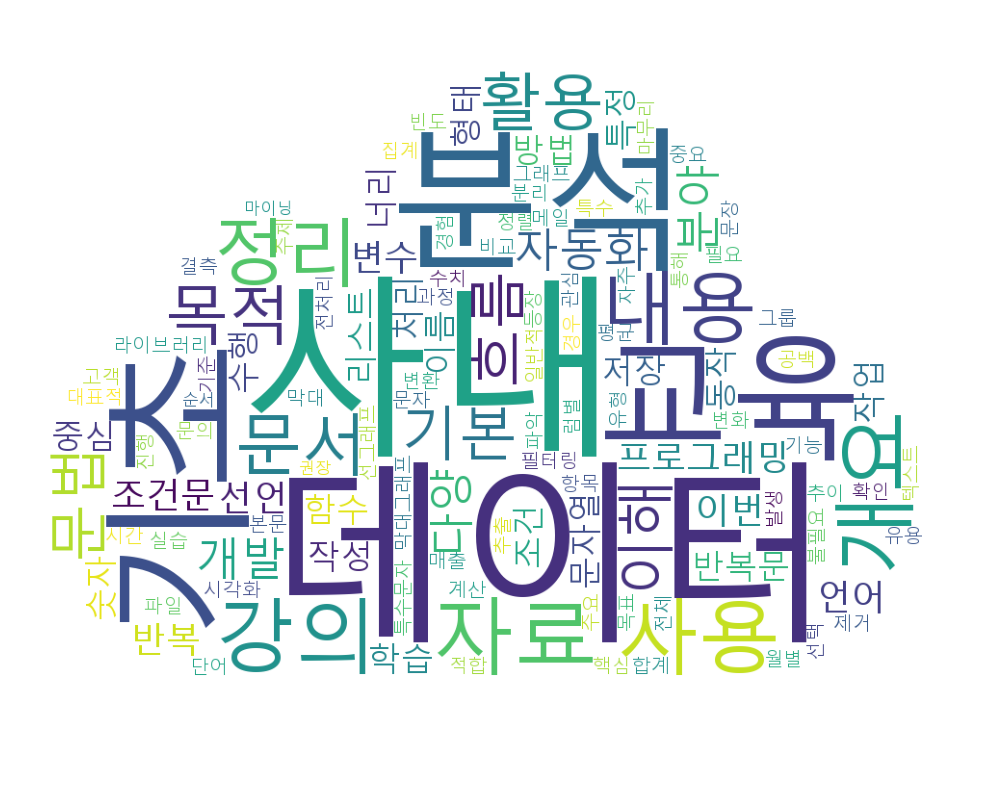

In [113]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordc = WordCloud(
    font_path="C:/Windows/Fonts/malgun.ttf",
    background_color="white",
    relative_scaling=0.2,
    mask=mask_ar)
wordc.generate(text)

plt.figure(figsize=(15,10))
plt.imshow(wordc)
plt.axis("off")
plt.show()

In [114]:
import nltk
print(nltk.__version__)

3.9.4
